# 01 - Tổng quan dữ liệu và tính chất dữ liệu
**Phụ trách: Lê Đăng Tiến (TV1)**. Nội dung: khảo sát bài toán, kích thước, kiểu dữ liệu, phân loại 4 nhóm biến theo paper De Cock (2011).

**Bài toán:** hồi quy có giám sát, dự đoán `SalePrice` (USD) của căn nhà ở Ames, Iowa (2006-2010). Kaggle chấm bằng RMSE trên log của giá.

In [1]:
import sys; sys.path.append('../src')
from eda_utils import *
train, test = load()
print(train.shape, test.shape)

(1460, 81) (1459, 80)


## 1. Kích thước và kiểu dữ liệu

In [2]:
feat = [c for c in train.columns if c not in ('Id','SalePrice')]
print('Số biến giải thích:', len(feat))
print('Train có SalePrice:', 'SalePrice' in train.columns, '| Test có SalePrice:', 'SalePrice' in test.columns)
print(train.dtypes.value_counts())
print('Dòng trùng lặp (train):', train.duplicated().sum(), '| Id trùng:', train.Id.duplicated().sum())

Số biến giải thích: 79
Train có SalePrice: True | Test có SalePrice: False
str        43
int64      35
float64     3
Name: count, dtype: int64
Dòng trùng lặp (train): 0 | Id trùng: 0


## 2. Phân loại biến thành 4 nhóm (nominal / ordinal / discrete / continuous)
Đối chiếu với paper: 23 nominal, 23 ordinal, 14 discrete, 20 continuous (20 gồm cả `SalePrice`, nên còn 19 biến liên tục giải thích).

In [3]:
assert set(GROUP_OF) == set(feat), set(feat) ^ set(GROUP_OF)   # 79 biến phải được phân loại đủ, không thừa
desc = descriptions()
rows = []
for c in feat:
    rows.append({'Biến': c, 'Nhóm': GROUP_OF[c], 'Kiểu pandas': str(train[c].dtype), 'Số giá trị khác nhau': train[c].nunique(),
                 'Thiếu (train)': int(train[c].isna().sum()), 'Thiếu (test)': int(test[c].isna().sum()), 'Ý nghĩa': desc.get(c, '')})
vt = pd.DataFrame(rows)
vt.to_csv(f'{RES}/bang_mo_ta_bien.csv', index=False, encoding='utf-8-sig')
cnt = vt.Nhóm.value_counts()
print(cnt.to_dict(), '| tổng =', cnt.sum())
print(pd.crosstab(vt.Nhóm, vt['Kiểu pandas']))

{'nominal': 23, 'ordinal': 23, 'continuous': 19, 'discrete': 14} | tổng = 79
Kiểu pandas  float64  int64  str
Nhóm                            
continuous         2     17    0
discrete           1     13    0
nominal            0      1   22
ordinal            0      2   21


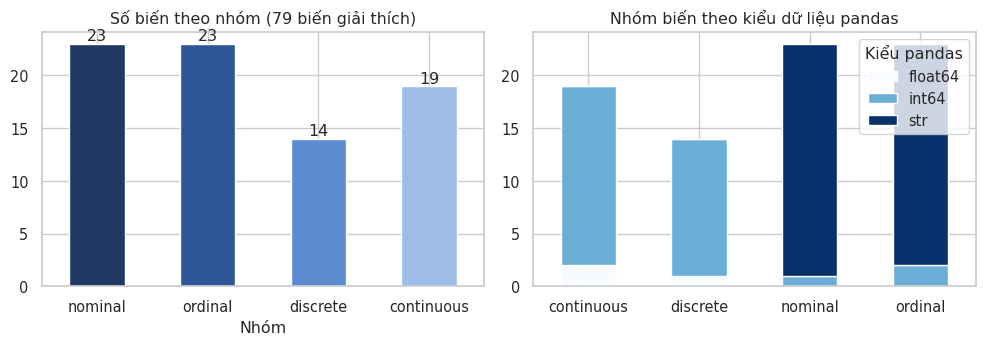

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
cnt.reindex(['nominal','ordinal','discrete','continuous']).plot.bar(ax=ax[0], color=['#1F3864','#2E5597','#5B8BD0','#9DBCE8'], rot=0)
ax[0].set_title('Số biến theo nhóm (79 biến giải thích)'); ax[0].bar_label(ax[0].containers[0])
pd.crosstab(vt.Nhóm, vt['Kiểu pandas']).plot.bar(stacked=True, ax=ax[1], rot=0, colormap='Blues')
ax[1].set_title('Nhóm biến theo kiểu dữ liệu pandas'); ax[1].set_xlabel('')
save_fig('01_nhom_bien')

**Lưu ý:** một số biến lưu dạng số nhưng bản chất là phân loại/định danh (`MSSubClass`) hoặc thứ bậc (`OverallQual`, `OverallCond`); `MoSold`, `YrSold` là rời rạc nhưng mang tính thời gian/mùa vụ. Không nên xem chúng là biến liên tục khi mô hình hóa.

In [5]:
coded = [c for c in feat if str(train[c].dtype) != 'object' and str(train[c].dtype)[:3] != 'str' and GROUP_OF[c] in ('nominal','ordinal')]
print('Biến lưu kiểu số nhưng là nominal/ordinal:', coded)

Biến lưu kiểu số nhưng là nominal/ordinal: ['MSSubClass', 'OverallQual', 'OverallCond']


## 3. Thống kê mô tả

In [6]:
num = [c for c in feat if GROUP_OF[c] in ('continuous','discrete')]
d = train[num + ['SalePrice']].describe().T
d['skew'] = train[num + ['SalePrice']].skew()
d.round(2).to_csv(f'{RES}/thong_ke_mo_ta_bien_so.csv', encoding='utf-8-sig')
display(d.round(2))

,count,mean,std,min,25%,50%,75%,max,skew
LotFrontage,1201.0,70.05,24.28,21.0,59.00,69.0,80.00,313.0,2.16
LotArea,1460.0,10516.83,9981.26,1300.0,7553.50,9478.5,11601.50,215245.0,12.21
YearBuilt,1460.0,1971.27,30.20,1872.0,1954.00,1973.0,2000.00,2010.0,-0.61
YearRemodAdd,1460.0,1984.87,20.65,1950.0,1967.00,1994.0,2004.00,2010.0,-0.50
MasVnrArea,1452.0,103.69,181.07,0.0,0.00,0.0,166.00,1600.0,2.67
BsmtFinSF1,1460.0,443.64,456.10,0.0,0.00,383.5,712.25,5644.0,1.69
BsmtFinSF2,1460.0,46.55,161.32,0.0,0.00,0.0,0.00,1474.0,4.26
BsmtUnfSF,1460.0,567.24,441.87,0.0,223.00,477.5,808.00,2336.0,0.92
TotalBsmtSF,1460.0,1057.43,438.71,0.0,795.75,991.5,1298.25,6110.0,1.52
1stFlrSF,1460.0,1162.63,386.59,334.0,882.00,1087.0,1391.25,4692.0,1.38


In [7]:
cat = [c for c in feat if GROUP_OF[c] in ('nominal','ordinal') and (str(train[c].dtype) == 'object' or str(train[c].dtype)[:3] == 'str')]
display(train[cat].describe().T.sort_values('unique', ascending=False).head(10))
print(train.SalePrice.describe())

,count,unique,top,freq
Neighborhood,1460,25,NAmes,225
Exterior2nd,1460,16,VinylSd,504
Exterior1st,1460,15,VinylSd,515
SaleType,1460,9,WD,1267
Condition1,1460,9,Norm,1260
Condition2,1460,8,Norm,1445
HouseStyle,1460,8,1Story,726
RoofMatl,1460,8,CompShg,1434
Functional,1460,7,Typ,1360
BsmtFinType2,1422,6,Unf,1256


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


## 4. So sánh dữ liệu trong paper và trong Kaggle

In [8]:
cmp = pd.DataFrame({'Tiêu chí': ['Số quan sát', 'Số biến giải thích', 'Nhóm biến (nominal/ordinal/discrete/continuous)', 'Neighborhood', 'Ghi chú'],
  'Paper De Cock (2011)': ['2930', '80 (+ PID, SalePrice)', '23 / 23 / 14 / 20 (gồm SalePrice)', '28 nhóm', 'Toàn bộ giao dịch 2006-2010'],
  'Kaggle (dữ liệu của nhóm)': [f'train {len(train)} + test {len(test)} = {len(train)+len(test)}', f'{len(feat)} (+ Id, SalePrice)',
     ' / '.join(str(cnt[k]) for k in ['nominal','ordinal','discrete','continuous']) + ' (+ SalePrice)', f'{train.Neighborhood.nunique()} nhóm trong train', 'Test không có SalePrice']})
display(cmp)
save_json('nb01', {'n_train': len(train), 'n_test': len(test), 'n_cols_train': train.shape[1], 'n_cols_test': test.shape[1], 'n_feat': len(feat),
  'groups': cnt.to_dict(), 'n_object': len(cat), 'coded_cat': coded, 'skew_saleprice': train.SalePrice.skew(), 'dup_rows': int(train.duplicated().sum()),
  'n_neigh_train': train.Neighborhood.nunique(), 'n_neigh_test': test.Neighborhood.nunique()})

,Tiêu chí,Paper De Cock (2011),Kaggle (dữ liệu của nhóm)
0,Số quan sát,2930,train 1460 + test 1459 = 2919
1,Số biến giải thích,"80 (+ PID, SalePrice)","79 (+ Id, SalePrice)"
2,Nhóm biến (nominal/ordinal/discrete/continuous),23 / 23 / 14 / 20 (gồm SalePrice),23 / 23 / 14 / 19 (+ SalePrice)
3,Neighborhood,28 nhóm,25 nhóm trong train
4,Ghi chú,Toàn bộ giao dịch 2006-2010,Test không có SalePrice
